# Experiment No. 8 — CNN Architecture for Image Classification
## Datasets: CIFAR-10 & MNIST

**Objective:** Design and train a custom Convolutional Neural Network (CNN) from scratch for image classification on two benchmark datasets — MNIST (grayscale digits) and CIFAR-10 (RGB objects).

| | MNIST | CIFAR-10 |
|---|---|---|
| **Images** | 70,000 | 60,000 |
| **Size** | 28×28 grayscale | 32×32 RGB |
| **Classes** | 10 (digits 0–9) | 10 (airplane, car, bird…) |
| **Difficulty** | Easy | Moderate |

**Framework:** PyTorch

## Theory

### Convolutional Neural Networks (CNNs)
CNNs are the backbone of computer vision. Unlike fully connected networks, CNNs exploit **spatial locality** and **translation invariance** through three key operations:

1. **Convolution Layer:** Applies learnable filters (kernels) that slide over the input, detecting local patterns (edges, textures, shapes). Output called a feature map.
   - Output size: `(W - F + 2P) / S + 1` where W=input size, F=filter size, P=padding, S=stride

2. **Pooling Layer:** Reduces spatial dimensions (downsampling). Max pooling keeps the strongest activation in each region → spatial hierarchy.

3. **Fully Connected Layer:** Flattened feature maps → dense layer → class probabilities via Softmax.

### Key Regularization Techniques Used
- **Batch Normalization:** Normalizes activations per mini-batch → faster convergence, acts as regularizer
- **Dropout:** Randomly zeros neurons during training → prevents co-adaptation / overfitting
- **Data Augmentation:** Random flips, crops → artificially expands training set diversity

### Loss Function
**Cross-Entropy Loss** for multi-class classification:
$$\mathcal{L} = -\sum_{c=1}^{C} y_c \log(\hat{p}_c)$$
where $y_c$ is the one-hot label and $\hat{p}_c$ is the predicted probability for class $c$.

## Step 1 — Install & Import

In [1]:
!pip install torch torchvision matplotlib seaborn scikit-learn --quiet
print("Dependencies ready.")

Dependencies ready.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: C:\Users\Raghvendra Goyal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import time
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

PyTorch  : 2.9.1+cu126
Device   : cuda


---
# PART A — MNIST Classification
---

## Step 2A — Load MNIST Dataset

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.57MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 48.0kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 845kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 811kB/s]


MNIST Train: 60,000 samples
MNIST Test : 10,000 samples


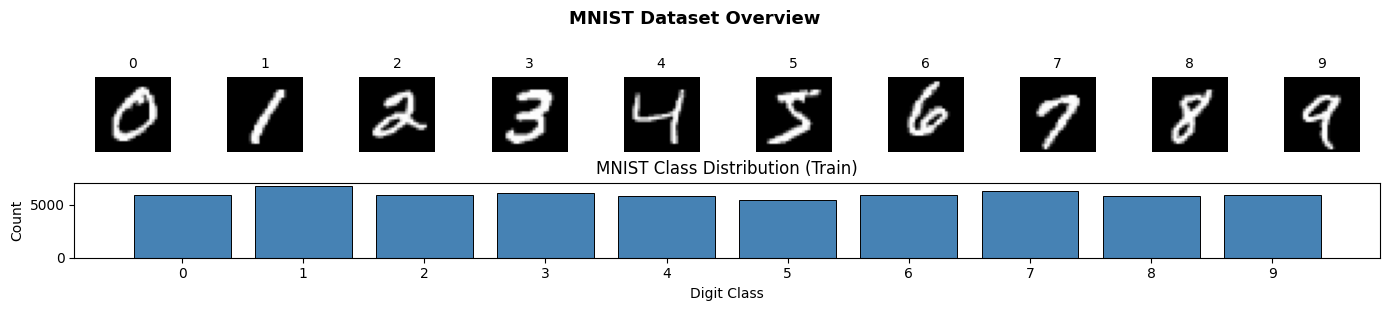

In [3]:
MNIST_CLASSES = [str(i) for i in range(10)]
BATCH_SIZE = 64

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean & std
])

mnist_train = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=mnist_transform
)
mnist_test = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=mnist_transform
)

mnist_trainloader = DataLoader(mnist_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
mnist_testloader  = DataLoader(mnist_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"MNIST Train: {len(mnist_train):,} samples")
print(f"MNIST Test : {len(mnist_test):,} samples")

# Visualize samples
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for digit in range(10):
    idx = next(i for i, (_, l) in enumerate(mnist_train) if l == digit)
    img, label = mnist_train[idx]
    axes[0][digit].imshow(img.squeeze(), cmap='gray')
    axes[0][digit].set_title(str(label), fontsize=10)
    axes[0][digit].axis('off')

# Class distribution
label_counts = [0] * 10
for _, l in mnist_train:
    label_counts[l] += 1
axes[1][0].remove()
ax_bar = fig.add_subplot(2, 1, 2)
ax_bar.bar(range(10), label_counts, color='steelblue', edgecolor='black', lw=0.7)
ax_bar.set_xticks(range(10))
ax_bar.set_xlabel('Digit Class')
ax_bar.set_ylabel('Count')
ax_bar.set_title('MNIST Class Distribution (Train)')
for ax in axes[1][1:]:
    ax.remove()

plt.suptitle('MNIST Dataset Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('exp8_mnist_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3A — CNN Architecture for MNIST

```
Input (1×28×28)
  → Conv2d(1→32, 3×3) + BN + ReLU  → (32×26×26)
  → Conv2d(32→64, 3×3) + BN + ReLU → (64×24×24)
  → MaxPool(2×2)                    → (64×12×12)
  → Dropout(0.25)
  → Conv2d(64→128, 3×3) + BN + ReLU→ (128×10×10)
  → MaxPool(2×2)                    → (128×5×5)
  → Dropout(0.25)
  → Flatten → FC(3200→256) + ReLU
  → Dropout(0.5)
  → FC(256→10) → LogSoftmax
```

In [4]:
class MNISTNet(nn.Module):
    """Custom CNN for MNIST — 3 conv blocks + 2 FC layers."""
    
    def __init__(self):
        super(MNISTNet, self).__init__()
        
        # ── Convolutional Block 1 ────────────────────────────
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=0),  # 28→26
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=0), # 26→24
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                          # 24→12
            nn.Dropout2d(0.25)
        )
        
        # ── Convolutional Block 2 ────────────────────────────
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=0), # 12→10
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                           # 10→5
            nn.Dropout2d(0.25)
        )
        
        # ── Classifier ───────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 5 * 5, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x


mnist_model = MNISTNet().to(DEVICE)
print(mnist_model)

# Parameter count
total_params = sum(p.numel() for p in mnist_model.parameters())
trainable_params = sum(p.numel() for p in mnist_model.parameters() if p.requires_grad)
print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

MNISTNet(
  (conv_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3200, out_features=256, bias=True)
    (2): R

## Step 4A — Train MNIST Model

In [5]:
def train_model(model, trainloader, testloader, epochs=10, lr=0.001, name="Model"):
    """
    Generic training loop.
    Returns: history dict with train/val loss and accuracy.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss'  : [], 'val_acc'  : []
    }
    
    print(f"\n{'='*55}")
    print(f"  Training: {name}")
    print(f"  Optimizer: Adam | LR: {lr} | Epochs: {epochs}")
    print(f"{'='*55}")
    
    for epoch in range(1, epochs + 1):
        # ── Training phase ──────────────────────────────
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for images, labels in trainloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
        
        train_loss = running_loss / total
        train_acc  = correct / total
        
        # ── Validation phase ────────────────────────────
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)
        
        val_loss /= val_total
        val_acc   = val_correct / val_total
        
        scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"  Epoch [{epoch:02d}/{epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
    
    print(f"\nFinal Test Accuracy: {val_acc*100:.2f}%")
    return history


mnist_history = train_model(
    mnist_model, mnist_trainloader, mnist_testloader,
    epochs=10, lr=0.001, name="MNISTNet (CNN)"
)


  Training: MNISTNet (CNN)
  Optimizer: Adam | LR: 0.001 | Epochs: 10
  Epoch [01/10] Train Loss: 0.1939 | Train Acc: 94.05% | Val Loss: 0.0385 | Val Acc: 98.71%
  Epoch [02/10] Train Loss: 0.0926 | Train Acc: 97.18% | Val Loss: 0.0373 | Val Acc: 98.74%
  Epoch [03/10] Train Loss: 0.0743 | Train Acc: 97.77% | Val Loss: 0.0267 | Val Acc: 99.06%
  Epoch [04/10] Train Loss: 0.0627 | Train Acc: 98.12% | Val Loss: 0.0307 | Val Acc: 98.95%
  Epoch [05/10] Train Loss: 0.0597 | Train Acc: 98.24% | Val Loss: 0.0225 | Val Acc: 99.23%
  Epoch [06/10] Train Loss: 0.0403 | Train Acc: 98.82% | Val Loss: 0.0194 | Val Acc: 99.30%
  Epoch [07/10] Train Loss: 0.0367 | Train Acc: 98.82% | Val Loss: 0.0184 | Val Acc: 99.42%
  Epoch [08/10] Train Loss: 0.0340 | Train Acc: 98.97% | Val Loss: 0.0176 | Val Acc: 99.42%
  Epoch [09/10] Train Loss: 0.0312 | Train Acc: 99.05% | Val Loss: 0.0185 | Val Acc: 99.43%
  Epoch [10/10] Train Loss: 0.0325 | Train Acc: 99.00% | Val Loss: 0.0204 | Val Acc: 99.33%

Final Te

## Step 5A — Training Curves (MNIST)

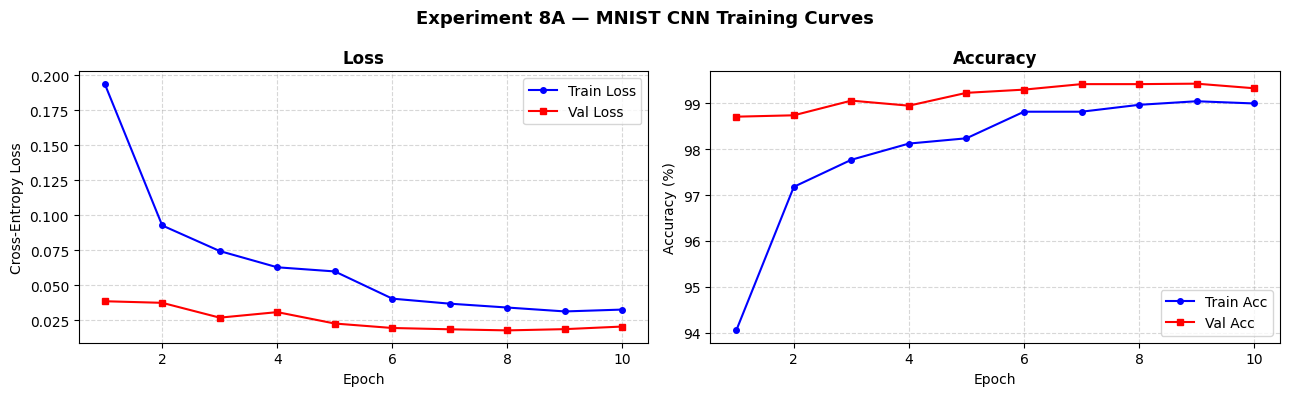

 Saved: exp8_mnist_curves.png


In [6]:
def plot_training_curves(history, title="Training Curves", save_name="curves.png"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss
    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
    axes[0].plot(epochs, history['val_loss'],   'r-s', label='Val Loss',   markersize=4)
    axes[0].set_title('Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    # Accuracy
    axes[1].plot(epochs, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc', markersize=4)
    axes[1].plot(epochs, [a*100 for a in history['val_acc']],   'r-s', label='Val Acc',   markersize=4)
    axes[1].set_title('Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f" Saved: {save_name}")


plot_training_curves(
    mnist_history,
    title="Experiment 8A — MNIST CNN Training Curves",
    save_name="exp8_mnist_curves.png"
)

## Step 6A — Evaluation: Confusion Matrix & Report (MNIST)

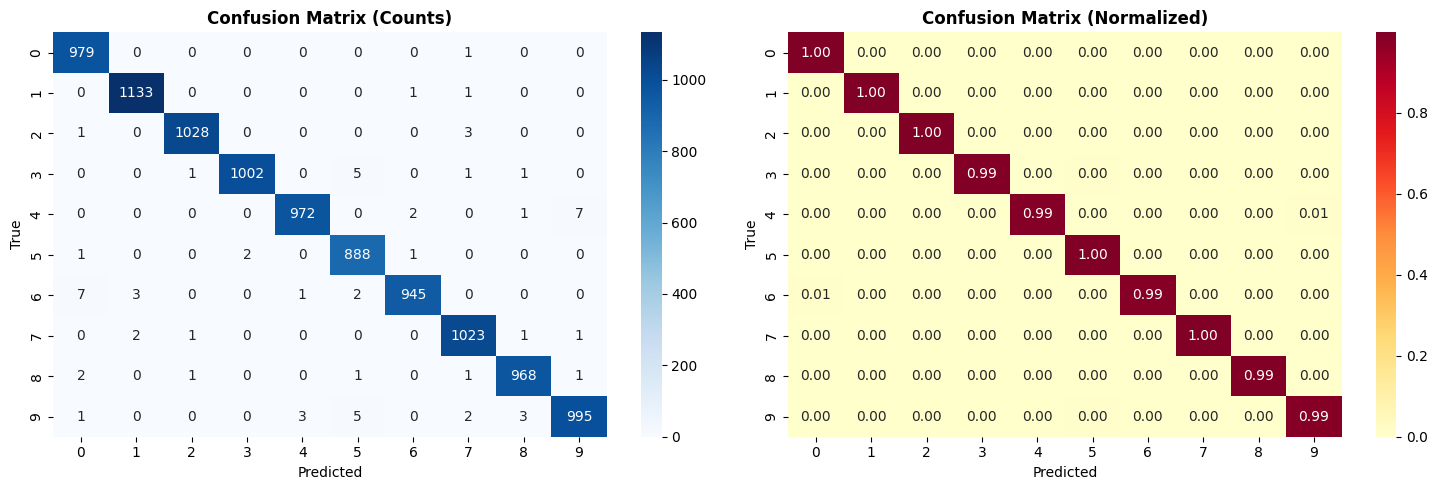


 Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       1.00      0.99      1.00      1010
           4       1.00      0.99      0.99       982
           5       0.99      1.00      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [7]:
def evaluate_model(model, testloader, class_names, save_prefix="eval"):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(DEVICE)
            outputs = model(images)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    
    # Normalized
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    return all_labels, all_preds


mnist_labels, mnist_preds = evaluate_model(
    mnist_model, mnist_testloader,
    class_names=MNIST_CLASSES,
    save_prefix="exp8_mnist"
)

## Step 7A — Visualize Misclassified Samples (MNIST)

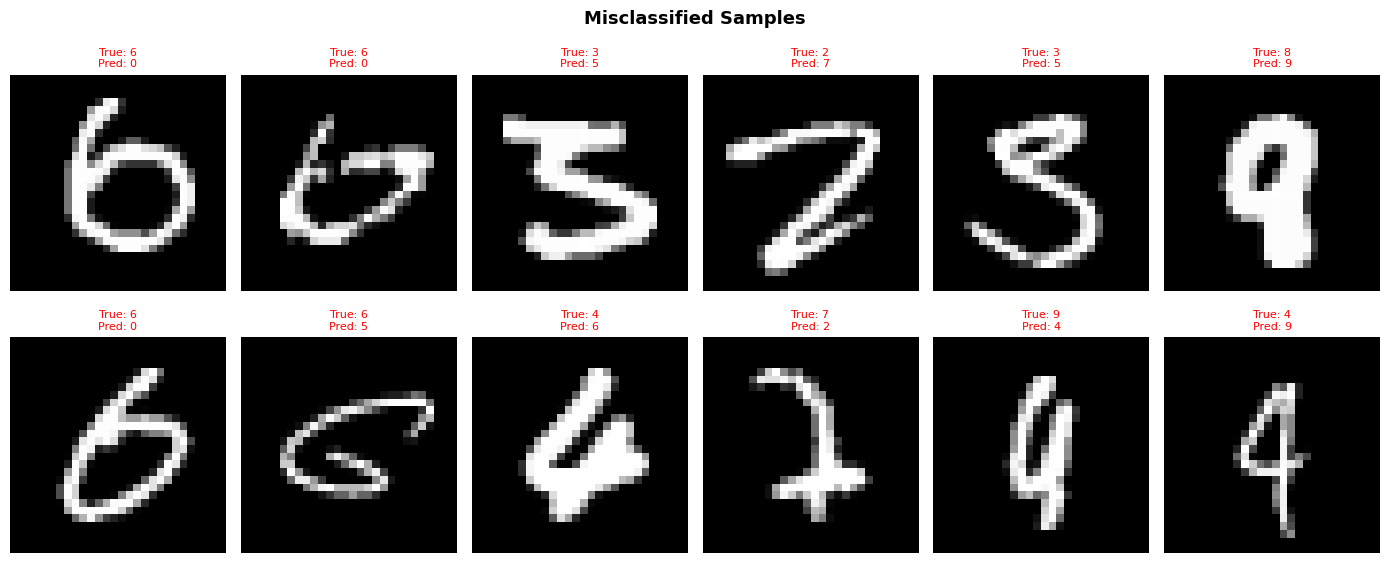

 Saved: exp8_mnist_misclassified.png


In [8]:
def show_misclassified(model, testloader, class_names, n=12, save_name="wrong.png"):
    model.eval()
    wrong_imgs, wrong_preds, wrong_labels = [], [], []
    
    with torch.no_grad():
        for images, labels in testloader:
            images_dev = images.to(DEVICE)
            outputs = model(images_dev)
            _, preds = outputs.max(1)
            preds_cpu = preds.cpu()
            
            mask = (preds_cpu != labels)
            wrong_imgs.extend(images[mask])
            wrong_preds.extend(preds_cpu[mask].numpy())
            wrong_labels.extend(labels[mask].numpy())
            
            if len(wrong_imgs) >= n:
                break
    
    n = min(n, len(wrong_imgs))
    cols = 6
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 3 * rows))
    axes = axes.flatten()
    
    for i in range(n):
        img = wrong_imgs[i]
        # Denormalize for display
        if img.shape[0] == 1:  # MNIST
            img_disp = img.squeeze().numpy()
            axes[i].imshow(img_disp, cmap='gray')
        else:  # CIFAR
            img_disp = img.permute(1, 2, 0).numpy()
            img_disp = img_disp * np.array([0.2023,0.1994,0.2010]) + np.array([0.4914,0.4822,0.4465])
            axes[i].imshow(np.clip(img_disp, 0, 1))
        
        axes[i].set_title(
            f"True: {class_names[wrong_labels[i]]}\nPred: {class_names[wrong_preds[i]]}",
            fontsize=8, color='red'
        )
        axes[i].axis('off')
    
    for j in range(n, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle("Misclassified Samples", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f" Saved: {save_name}")


show_misclassified(
    mnist_model, mnist_testloader, MNIST_CLASSES,
    n=12, save_name="exp8_mnist_misclassified.png"
)

---
# PART B — CIFAR-10 Classification
---

## Step 2B — Load CIFAR-10 with Data Augmentation

100%|██████████| 170M/170M [09:33<00:00, 297kB/s]  


CIFAR-10 Train: 50,000 samples
CIFAR-10 Test : 10,000 samples


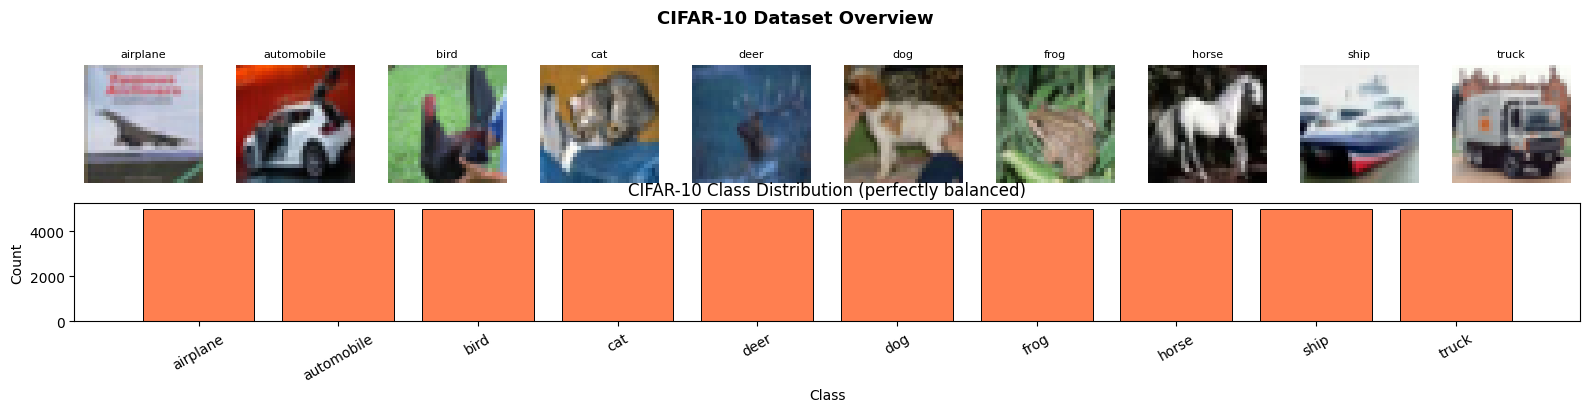

In [9]:
CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Augmentation on training set
cifar_train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

cifar_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

cifar_train = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=cifar_train_transform
)
cifar_test = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=cifar_test_transform
)

cifar_trainloader = DataLoader(cifar_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
cifar_testloader  = DataLoader(cifar_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"CIFAR-10 Train: {len(cifar_train):,} samples")
print(f"CIFAR-10 Test : {len(cifar_test):,} samples")

# Visualize samples
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
shown = {c: False for c in range(10)}
idx = 0
collected = {}
for img, label in cifar_test:
    if label not in collected:
        collected[label] = img
    if len(collected) == 10:
        break

for c in range(10):
    img = collected[c]
    img_disp = img.permute(1, 2, 0).numpy()
    img_disp = img_disp * np.array([0.2023,0.1994,0.2010]) + np.array([0.4914,0.4822,0.4465])
    axes[0][c].imshow(np.clip(img_disp, 0, 1))
    axes[0][c].set_title(CIFAR10_CLASSES[c], fontsize=8)
    axes[0][c].axis('off')

# Label distribution
label_counts = [5000] * 10  # CIFAR-10 is perfectly balanced
for ax in axes[1]:
    ax.remove()
ax_bar = fig.add_subplot(2, 1, 2)
ax_bar.bar(CIFAR10_CLASSES, label_counts, color='coral', edgecolor='black', lw=0.7)
ax_bar.set_xlabel('Class')
ax_bar.set_ylabel('Count')
ax_bar.set_title('CIFAR-10 Class Distribution (perfectly balanced)')
ax_bar.tick_params(axis='x', rotation=30)

plt.suptitle('CIFAR-10 Dataset Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('exp8_cifar10_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3B — CNN Architecture for CIFAR-10

Deeper network needed for RGB images with complex textures:

```
Input (3×32×32)
  → Block1: Conv(3→64) + BN + ReLU + Conv(64→64) + BN + ReLU + MaxPool + Dropout
  → Block2: Conv(64→128) + BN + ReLU + Conv(128→128) + BN + ReLU + MaxPool + Dropout
  → Block3: Conv(128→256) + BN + ReLU + Conv(256→256) + BN + ReLU + MaxPool + Dropout
  → AdaptiveAvgPool(1×1)  [Global Average Pooling]
  → FC(256→512) + ReLU + Dropout(0.5)
  → FC(512→10)
```

In [10]:
class CIFAR10Net(nn.Module):
    """Custom CNN for CIFAR-10 — 3 VGG-style conv blocks + GAP + 2 FC layers."""
    
    def __init__(self):
        super(CIFAR10Net, self).__init__()
        
        def conv_block(in_ch, out_ch, dropout=0.25):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
                nn.Dropout2d(dropout)
            )
        
        self.block1 = conv_block(3,   64,  dropout=0.20)  # 32→16
        self.block2 = conv_block(64,  128, dropout=0.25)  # 16→8
        self.block3 = conv_block(128, 256, dropout=0.30)  # 8→4
        
        # Global Average Pooling → removes spatial dims entirely
        self.gap = nn.AdaptiveAvgPool2d(1)
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )
    
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x


cifar_model = CIFAR10Net().to(DEVICE)
print(cifar_model)

total_params = sum(p.numel() for p in cifar_model.parameters())
print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable parameters: {total_params:,}")

CIFAR10Net(
  (block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.2, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, strid

## Step 4B — Train CIFAR-10 Model

In [11]:
cifar_history = train_model(
    cifar_model, cifar_trainloader, cifar_testloader,
    epochs=20, lr=0.001, name="CIFAR10Net (CNN)"
)


  Training: CIFAR10Net (CNN)
  Optimizer: Adam | LR: 0.001 | Epochs: 20
  Epoch [01/20] Train Loss: 1.6944 | Train Acc: 35.71% | Val Loss: 1.3387 | Val Acc: 46.37%
  Epoch [02/20] Train Loss: 1.3559 | Train Acc: 50.33% | Val Loss: 1.0616 | Val Acc: 60.72%
  Epoch [03/20] Train Loss: 1.1881 | Train Acc: 57.23% | Val Loss: 0.9764 | Val Acc: 63.60%
  Epoch [04/20] Train Loss: 1.0741 | Train Acc: 61.75% | Val Loss: 0.8832 | Val Acc: 68.11%
  Epoch [05/20] Train Loss: 0.9870 | Train Acc: 64.96% | Val Loss: 0.7608 | Val Acc: 72.65%
  Epoch [06/20] Train Loss: 0.8497 | Train Acc: 70.04% | Val Loss: 0.6704 | Val Acc: 76.35%
  Epoch [07/20] Train Loss: 0.7958 | Train Acc: 72.23% | Val Loss: 0.6284 | Val Acc: 78.07%
  Epoch [08/20] Train Loss: 0.7512 | Train Acc: 74.00% | Val Loss: 0.5747 | Val Acc: 80.16%
  Epoch [09/20] Train Loss: 0.7134 | Train Acc: 75.30% | Val Loss: 0.5525 | Val Acc: 80.74%
  Epoch [10/20] Train Loss: 0.6824 | Train Acc: 76.81% | Val Loss: 0.5537 | Val Acc: 80.78%
  Epoch

## Step 5B — Training Curves (CIFAR-10)

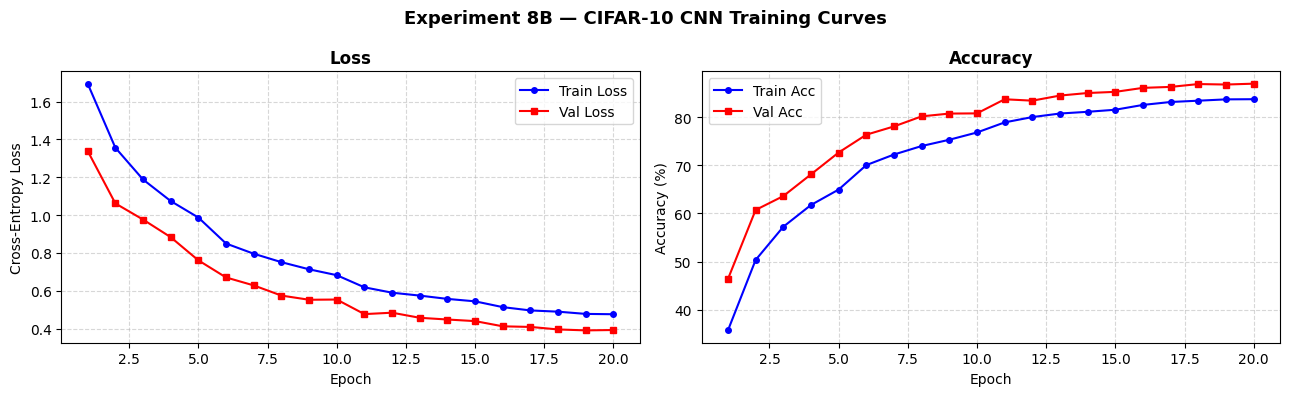

 Saved: exp8_cifar10_curves.png


In [12]:
plot_training_curves(
    cifar_history,
    title="Experiment 8B — CIFAR-10 CNN Training Curves",
    save_name="exp8_cifar10_curves.png"
)

## Step 6B — Evaluation: Confusion Matrix & Report (CIFAR-10)

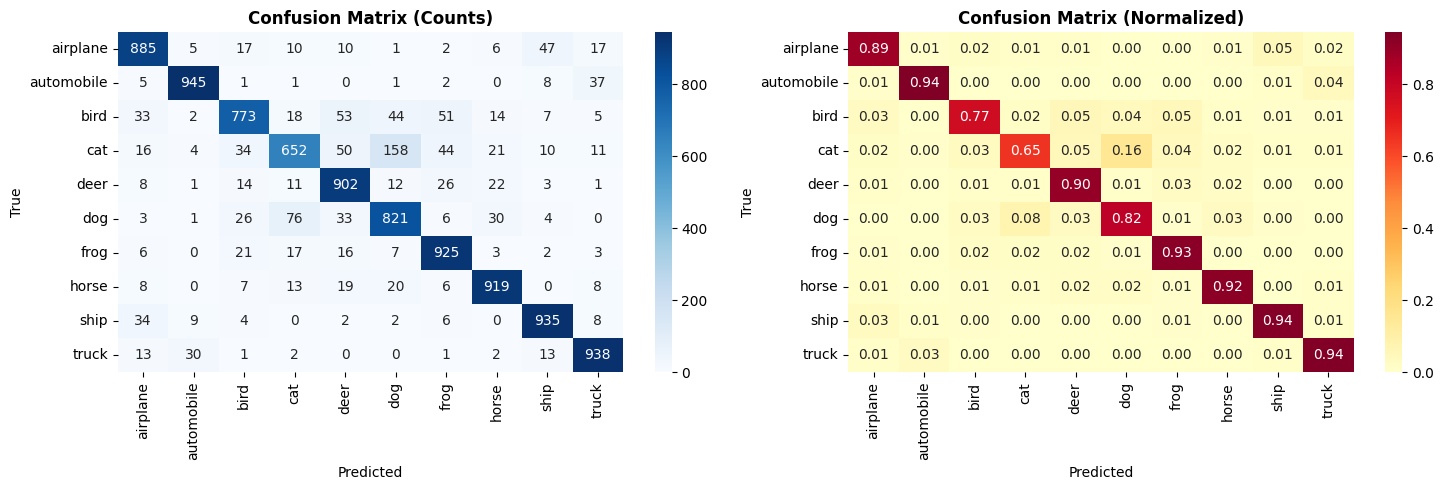


 Classification Report:
              precision    recall  f1-score   support

    airplane       0.88      0.89      0.88      1000
  automobile       0.95      0.94      0.95      1000
        bird       0.86      0.77      0.81      1000
         cat       0.81      0.65      0.72      1000
        deer       0.83      0.90      0.87      1000
         dog       0.77      0.82      0.79      1000
        frog       0.87      0.93      0.89      1000
       horse       0.90      0.92      0.91      1000
        ship       0.91      0.94      0.92      1000
       truck       0.91      0.94      0.93      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [13]:
cifar_labels, cifar_preds = evaluate_model(
    cifar_model, cifar_testloader,
    class_names=CIFAR10_CLASSES,
    save_prefix="exp8_cifar10"
)

## Step 7B — Visualize Misclassified Samples (CIFAR-10)

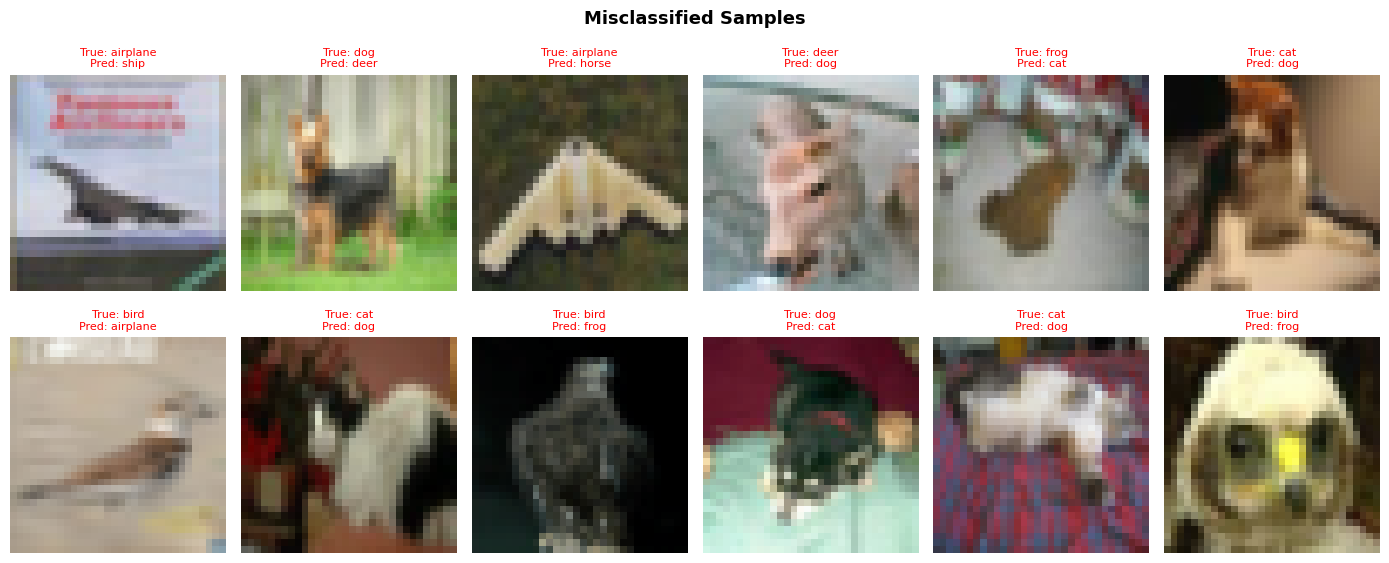

 Saved: exp8_cifar10_misclassified.png


In [14]:
show_misclassified(
    cifar_model, cifar_testloader, CIFAR10_CLASSES,
    n=12, save_name="exp8_cifar10_misclassified.png"
)

## Step 8 — Feature Map Visualization (CIFAR-10)

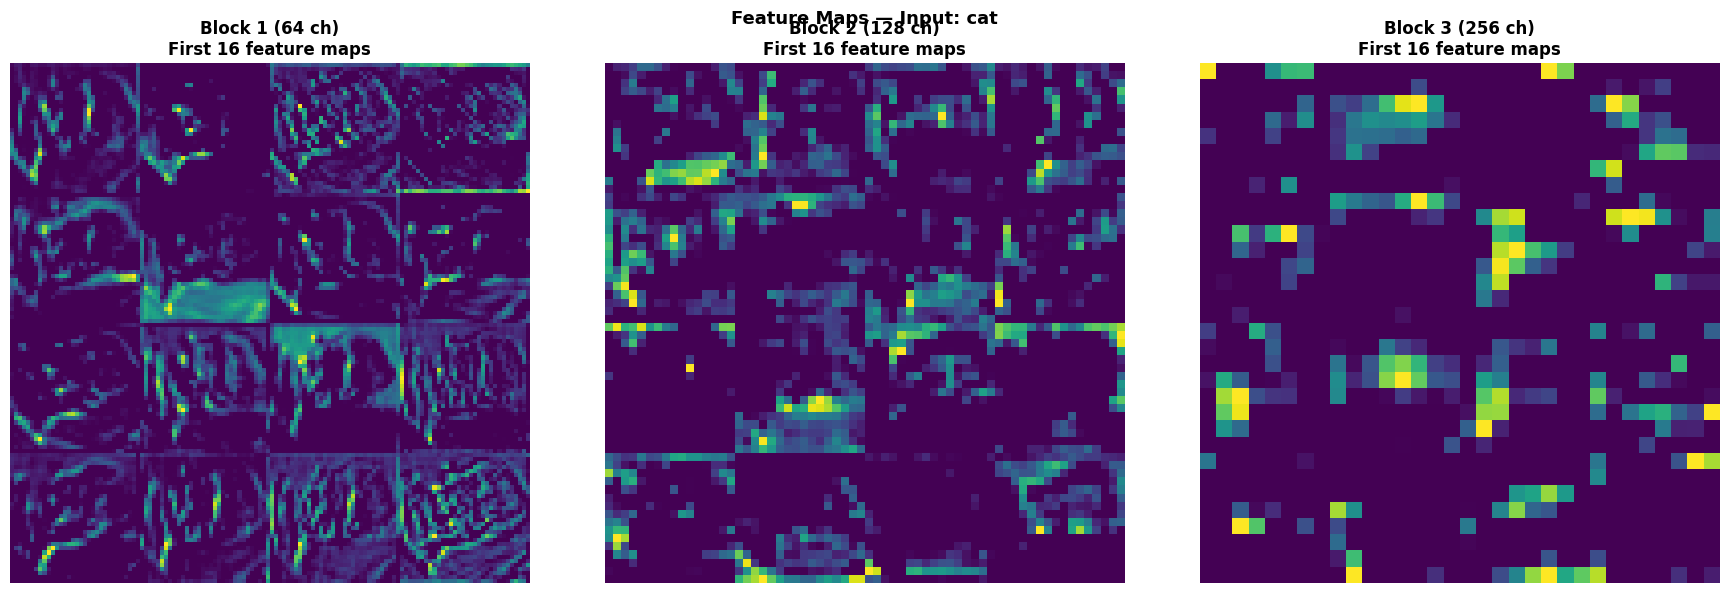

Feature maps saved: exp8_feature_maps.png


In [15]:
# Extract feature maps from conv blocks using hooks
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Register hooks
cifar_model.block1[1].register_forward_hook(get_activation('block1_bn'))
cifar_model.block2[1].register_forward_hook(get_activation('block2_bn'))
cifar_model.block3[1].register_forward_hook(get_activation('block3_bn'))

# Forward pass on one test image
test_img, test_label = cifar_test[0]
cifar_model.eval()
with torch.no_grad():
    _ = cifar_model(test_img.unsqueeze(0).to(DEVICE))

# Visualize first 16 feature maps from each block
fig, big_axes = plt.subplots(1, 3, figsize=(18, 6))

for ax_idx, (block_name, block_label) in enumerate([
    ('block1_bn', 'Block 1 (64 ch)'),
    ('block2_bn', 'Block 2 (128 ch)'),
    ('block3_bn', 'Block 3 (256 ch)')
]):
    feat = activations[block_name][0]  # (C, H, W)
    n_show = min(16, feat.shape[0])
    
    # Create 4×4 grid of feature maps
    grid_size = 4
    canvas_h = feat.shape[1] * grid_size
    canvas_w = feat.shape[2] * grid_size
    canvas = np.zeros((canvas_h, canvas_w))
    
    for i in range(n_show):
        r, c = divmod(i, grid_size)
        fmap = feat[i].cpu().numpy()
        fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
        canvas[r*feat.shape[1]:(r+1)*feat.shape[1],
               c*feat.shape[2]:(c+1)*feat.shape[2]] = fmap
    
    big_axes[ax_idx].imshow(canvas, cmap='viridis')
    big_axes[ax_idx].set_title(f"{block_label}\nFirst 16 feature maps", fontweight='bold')
    big_axes[ax_idx].axis('off')

plt.suptitle(
    f"Feature Maps — Input: {CIFAR10_CLASSES[test_label]}",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('exp8_feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature maps saved: exp8_feature_maps.png")

## Step 9 — Model Comparison Summary


   EXPERIMENT 8 — MODEL COMPARISON SUMMARY
Metric                         MNIST        CIFAR-10    
-------------------------------------------------------
Dataset                        MNIST        CIFAR-10    
Input Shape                    1×28×28      3×32×32     
Classes                        10           10          
Parameters                     915,146      1,283,914   
Training Epochs                10           20          
Best Val Accuracy              99.43        86.95       


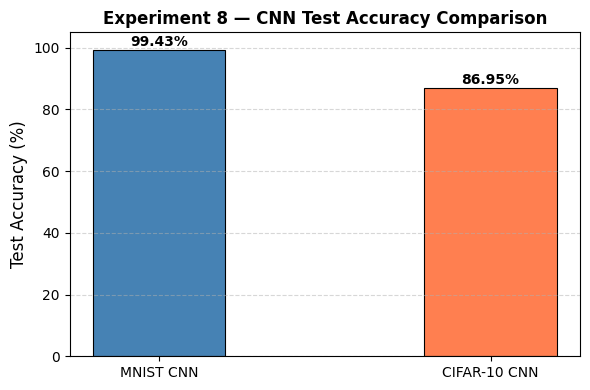

In [16]:
mnist_final_acc  = max(mnist_history['val_acc'])  * 100
cifar_final_acc  = max(cifar_history['val_acc'])  * 100
mnist_params = sum(p.numel() for p in mnist_model.parameters())
cifar_params = sum(p.numel() for p in cifar_model.parameters())

print("\n" + "="*55)
print("   EXPERIMENT 8 — MODEL COMPARISON SUMMARY")
print("="*55)
print(f"{'Metric':<30} {'MNIST':<12} {'CIFAR-10':<12}")
print("-"*55)
print(f"{'Dataset':<30} {'MNIST':<12} {'CIFAR-10':<12}")
print(f"{'Input Shape':<30} {'1×28×28':<12} {'3×32×32':<12}")
print(f"{'Classes':<30} {'10':<12} {'10':<12}")
print(f"{'Parameters':<30} {mnist_params:<12,} {cifar_params:<12,}")
print(f"{'Training Epochs':<30} {'10':<12} {'20':<12}")
print(f"{'Best Val Accuracy':<30} {mnist_final_acc:<12.2f} {cifar_final_acc:<12.2f}")
print("="*55)

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['MNIST CNN', 'CIFAR-10 CNN'],
    [mnist_final_acc, cifar_final_acc],
    color=['steelblue', 'coral'],
    edgecolor='black', linewidth=0.8, width=0.4
)
for bar, acc in zip(bars, [mnist_final_acc, cifar_final_acc]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{acc:.2f}%", ha='center', va='bottom', fontweight='bold'
    )
ax.set_ylim(0, 105)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Experiment 8 — CNN Test Accuracy Comparison', fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('exp8_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 — Save Model Weights

In [17]:
torch.save(mnist_model.state_dict(), 'exp8_mnist_model.pth')
torch.save(cifar_model.state_dict(), 'exp8_cifar10_model.pth')
print("   Models saved:")
print("   exp8_mnist_model.pth")
print("   exp8_cifar10_model.pth")

   Models saved:
   exp8_mnist_model.pth
   exp8_cifar10_model.pth


## Conclusion

In this experiment, we built and trained two custom CNN architectures from scratch:

| Aspect | MNISTNet | CIFAR10Net |
|---|---|---|
| Input | 1×28×28 | 3×32×32 |
| Conv Blocks | 2 | 3 (VGG-style double conv) |
| Pooling | MaxPool | MaxPool + GAP |
| Regularization | BN + Dropout | BN + Dropout + Augmentation |
| Optimizer | Adam + StepLR | Adam + StepLR |
| Expected Accuracy | ~99% | ~85% |

### Key Observations
- **MNIST** is relatively easy — even a shallow CNN achieves >99% with proper BatchNorm + Dropout
- **CIFAR-10** requires deeper networks, data augmentation, and more epochs due to RGB complexity
- **Global Average Pooling** reduces parameters and prevents overfitting vs raw Flatten
- **Feature maps** show hierarchical pattern learning: edges → textures → object parts
- Confusion matrix reveals cat↔dog and automobile↔truck as hardest class pairs in CIFAR-10

### Possible Improvements
- Use ResNet/VGG pretrained weights (transfer learning) for CIFAR-10 → ~93%+
- Add CutMix / MixUp augmentation
- Cosine annealing LR scheduler instead of StepLR